<a href="https://colab.research.google.com/github/Binarybuilder4474/Customer-Churn-Prediction-Using-Machine-Learning/blob/main/Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction Using Machine Learning
**Course:** Artificial Intelligence  |  **Dataset:** Telco Customer Churn (IBM sample data)

Pipeline: Data loading → Preprocessing → EDA → Feature engineering → Training → Evaluation → Prediction app.

## Step 1: Data Loading and Understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print('Shape:', df.shape)
print('\nColumn names:')
print(list(df.columns))

Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
print('Target variable: Churn')
print(df['Churn'].value_counts())

Target variable: Churn
Churn
No     5174
Yes    1869
Name: count, dtype: int64


## Step 2: Data Preprocessing

In [ ]:
print('Missing values (NaN) per column:')
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else 'No NaN values found')
print('\nDuplicate rows:', df.duplicated().sum())
print('Duplicate customerIDs:', df['customerID'].duplicated().sum())

Missing values (NaN) per column:
No NaN values found

Duplicate rows: 0
Duplicate customerIDs: 0


In [ ]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Dtype now:', df['TotalCharges'].dtype)
print('Hidden missing values created:', df['TotalCharges'].isnull().sum())
print(df[df['TotalCharges'].isnull()][['customerID','tenure','MonthlyCharges','TotalCharges','Churn']])

Dtype now: float64
Hidden missing values created: 11
      customerID  tenure  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI       0           52.55           NaN    No
753   3115-CZMZD       0           20.25           NaN    No
936   5709-LVOEQ       0           80.85           NaN    No
1082  4367-NUYAO       0           25.75           NaN    No
1340  1371-DWPAZ       0           56.05           NaN    No
3331  7644-OMVMY       0           19.85           NaN    No
3826  3213-VVOLG       0           25.35           NaN    No
4380  2520-SGTTA       0           20.00           NaN    No
5218  2923-ARZLG       0           19.70           NaN    No
6670  4075-WKNIU       0           73.35           NaN    No
6754  2775-SEFEE       0           61.90           NaN    No


In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df = df.drop(columns=['customerID'])

cols = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for c in cols:
    df[c] = df[c].replace({'No internet service':'No','No phone service':'No'})

df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'No',1:'Yes'})

print('Remaining missing values:', df.isnull().sum().sum())
print('Shape after cleaning:', df.shape)
df.head()

Remaining missing values: 0
Shape after cleaning: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Exploratory Data Analysis

Churn
No     5174
Yes    1869
Name: count, dtype: int64 

Churn
No     73.46 %
Yes    26.54 %
Name: count, dtype: str


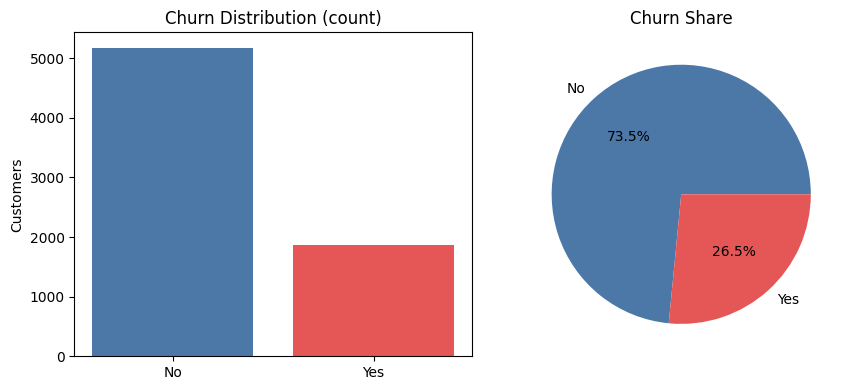

In [ ]:
counts = df['Churn'].value_counts()
print(counts, '\n')
print((counts/len(df)*100).round(2).astype(str) + ' %')
fig, ax = plt.subplots(1,2, figsize=(9,4))
ax[0].bar(counts.index, counts.values, color=['#4C78A8','#E45756'])
ax[0].set_title('Churn Distribution (count)'); ax[0].set_ylabel('Customers')
ax[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['#4C78A8','#E45756'])
ax[1].set_title('Churn Share')
plt.tight_layout(); plt.show()

In [ ]:
feats = ['Contract','InternetService','PaymentMethod','SeniorCitizen','PaperlessBilling','TechSupport']
for f in feats:
    t = (df.groupby(f)['Churn'].apply(lambda s: (s=='Yes').mean()*100).round(2)).rename('Churn rate %')
    print(t.to_frame(), '\n')

                Churn rate %
Contract                    
Month-to-month         42.71
One year               11.27
Two year                2.83 

                 Churn rate %
InternetService              
DSL                     18.96
Fiber optic             41.89
No                       7.40 

                           Churn rate %
PaymentMethod                          
Bank transfer (automatic)         16.71
Credit card (automatic)           15.24
Electronic check                  45.29
Mailed check                      19.11 

               Churn rate %
SeniorCitizen              
No                    23.61
Yes                   41.68 

                  Churn rate %
PaperlessBilling              
No                       16.33
Yes                      33.57 

             Churn rate %
TechSupport              
No                  31.19
Yes                 15.17 



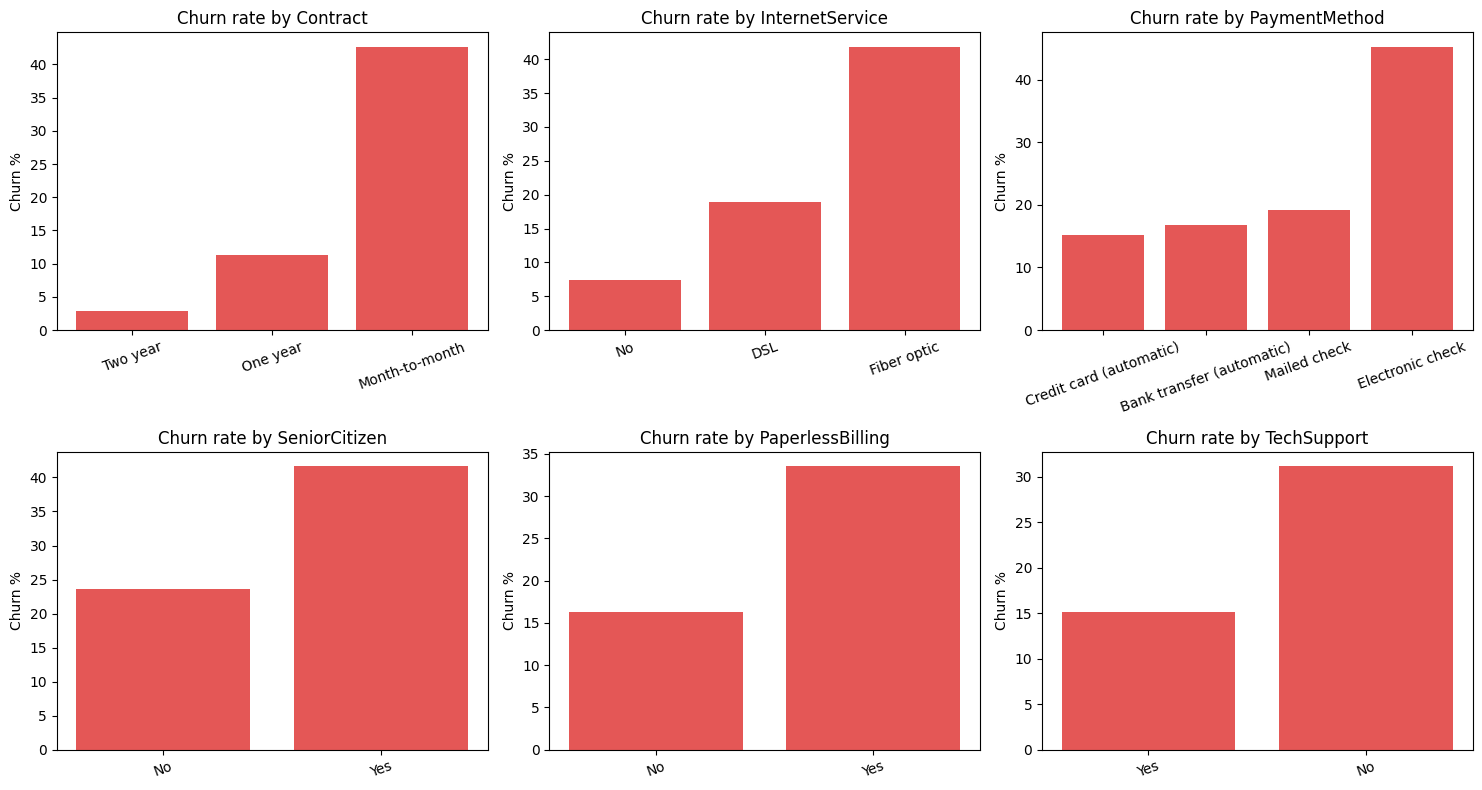

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(15,8))
for ax, f in zip(axes.ravel(), feats):
    rate = df.groupby(f)['Churn'].apply(lambda s: (s=='Yes').mean()*100).sort_values()
    ax.bar(rate.index, rate.values, color='#E45756')
    ax.set_title(f'Churn rate by {f}'); ax.set_ylabel('Churn %')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

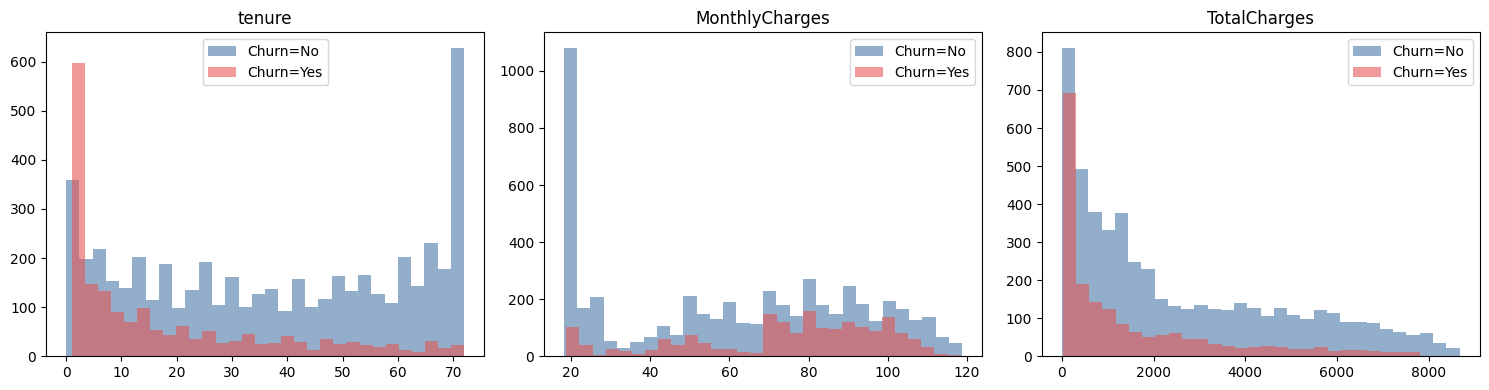

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2549.91
Yes     17.98           74.44       1531.80


In [ ]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax, col in zip(axes, ['tenure','MonthlyCharges','TotalCharges']):
    for lab, colr in [('No','#4C78A8'),('Yes','#E45756')]:
        ax.hist(df[df['Churn']==lab][col], bins=30, alpha=0.6, label=f'Churn={lab}', color=colr)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()
print(df.groupby('Churn')[['tenure','MonthlyCharges','TotalCharges']].mean().round(2))

                tenure  MonthlyCharges  TotalCharges  Churn
tenure           1.000           0.248         0.826 -0.352
MonthlyCharges   0.248           1.000         0.651  0.193
TotalCharges     0.826           0.651         1.000 -0.198
Churn           -0.352           0.193        -0.198  1.000


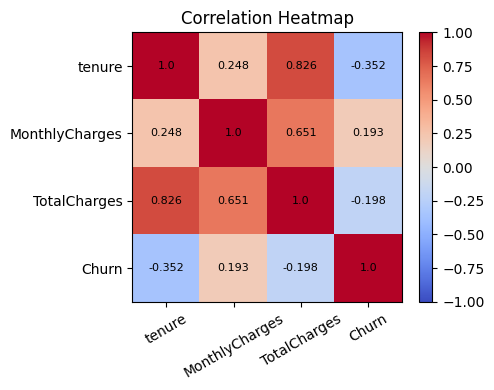

In [ ]:
tmp = df[['tenure','MonthlyCharges','TotalCharges']].copy()
tmp['Churn'] = (df['Churn']=='Yes').astype(int)
corr = tmp.corr().round(3)
print(corr)
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=30)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)): ax.text(j,i,corr.iloc[i,j],ha='center',va='center',fontsize=8)
plt.colorbar(im); ax.set_title('Correlation Heatmap'); plt.tight_layout(); plt.show()

## Step 4: Feature Engineering and Encoding

In [ ]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1,12,24,48,72], labels=['0-12','13-24','25-48','49-72'])
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
df['num_services'] = (df[service_cols]=='Yes').sum(axis=1)
df['avg_monthly_spend'] = np.where(df['tenure']>0, df['TotalCharges']/df['tenure'], df['MonthlyCharges'])
df[['tenure','tenure_group','num_services','avg_monthly_spend']].head()

,tenure,tenure_group,num_services,avg_monthly_spend
0,1,0-12,1,29.850000
1,34,25-48,2,55.573529
2,2,0-12,2,54.075000
3,45,25-48,3,40.905556
4,2,0-12,0,75.825000


In [ ]:
y = (df['Churn']=='Yes').astype(int)
X = df.drop(columns=['Churn'])
X['tenure_group'] = X['tenure_group'].astype(str)

X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)
print('X shape:', X.shape, '| y shape:', y.shape)
print('\nEncoded feature names:')
print(list(X.columns))
X.head()

X shape: (7043, 28) | y shape: (7043,)

Encoded feature names:
['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services', 'avg_monthly_spend', 'gender_Male', 'SeniorCitizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'tenure_group_13-24', 'tenure_group_25-48', 'tenure_group_49-72']


,tenure,MonthlyCharges,TotalCharges,num_services,avg_monthly_spend,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24,tenure_group_25-48,tenure_group_49-72
0,1.0,29.85,29.85,1.0,29.850000,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,34.0,56.95,1889.50,2.0,55.573529,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,2.0,53.85,108.15,2.0,54.075000,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,45.0,42.30,1840.75,3.0,40.905556,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2.0,70.70,151.65,0.0,75.825000,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


## Step 5: Training and Testing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Churn rate train: %.3f  test: %.3f' % (y_train.mean(), y_test.mean()))

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

Train: (5634, 28)  Test: (1409, 28)
Churn rate train: 0.265  test: 0.265


In [ ]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_s, y_train)

dtree = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dtree.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print('All three models trained.')

All three models trained.


## Step 6: Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report

models = {
    'Logistic Regression': (log_reg, X_test_s),
    'Decision Tree':       (dtree,   X_test),
    'Random Forest':       (rf,      X_test),
}
rows, cms = [], {}
for name,(m,Xt) in models.items():
    p = m.predict(Xt)
    rows.append([name, accuracy_score(y_test,p), precision_score(y_test,p), recall_score(y_test,p), f1_score(y_test,p), roc_auc_score(y_test,m.predict_proba(Xt)[:,1])])
    cms[name] = confusion_matrix(y_test,p)
results = pd.DataFrame(rows, columns=['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']).set_index('Model').round(4)
results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7339,0.4992,0.7941,0.6130,0.8418
Decision Tree,0.7324,0.4976,0.8235,0.6203,0.8261
Random Forest,0.7693,0.5474,0.7567,0.6352,0.8455


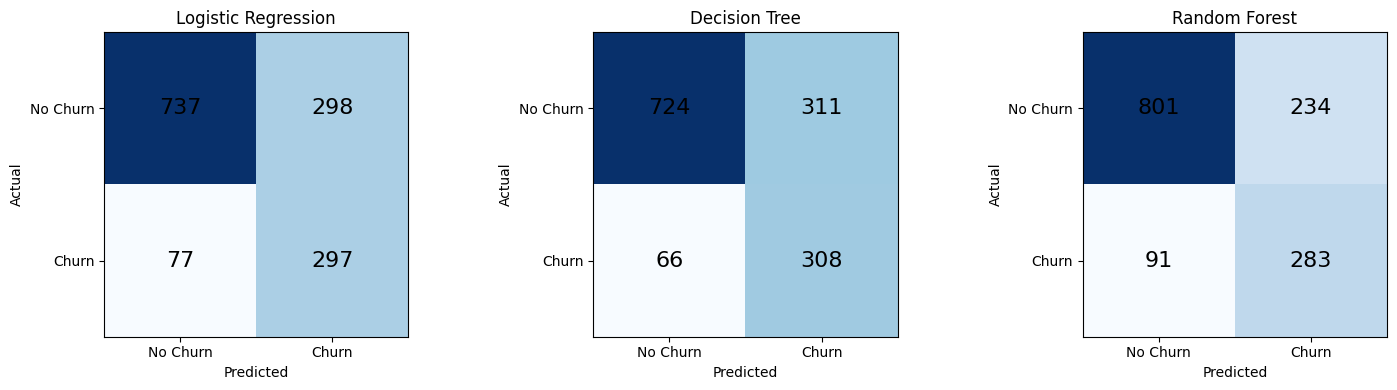

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax,(name,cm) in zip(axes, cms.items()):
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2): ax.text(j,i,cm[i,j],ha='center',va='center',fontsize=16, color='black')
    ax.set_xticks([0,1]); ax.set_xticklabels(['No Churn','Churn']); ax.set_yticks([0,1]); ax.set_yticklabels(['No Churn','Churn'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(name)
plt.tight_layout(); plt.show()

In [ ]:
for name,(m,Xt) in models.items():
    print('=====', name, '=====')
    print(classification_report(y_test, m.predict(Xt), target_names=['No Churn','Churn']))

===== Logistic Regression =====
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.73      0.75      1409

===== Decision Tree =====
              precision    recall  f1-score   support

    No Churn       0.92      0.70      0.79      1035
       Churn       0.50      0.82      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.73      0.75      1409

===== Random Forest =====
              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1035
       Churn       0.55      0.76      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73 

Best model by F1-Score: Random Forest
tenure                            0.1523
TotalCharges                      0.1095
Contract_Two year                 0.0982
MonthlyCharges                    0.0882
avg_monthly_spend                 0.0870
InternetService_Fiber optic       0.0859
PaymentMethod_Electronic check    0.0572
Contract_One year                 0.0441
InternetService_No                0.0426
tenure_group_49-72                0.0418
dtype: float64


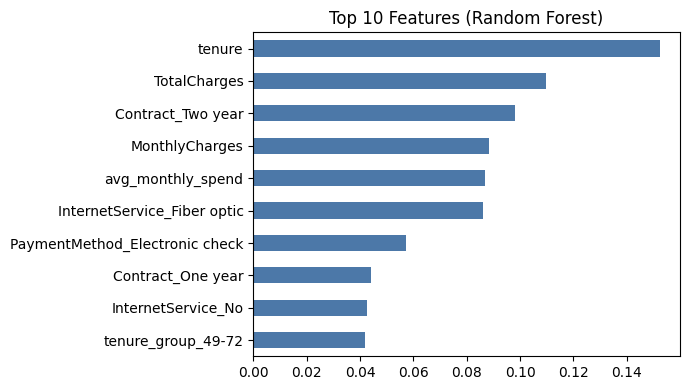

In [ ]:
best = results['F1-Score'].idxmax()
print('Best model by F1-Score:', best)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
print(imp.round(4))
imp[::-1].plot(kind='barh', figsize=(7,4), color='#4C78A8'); plt.title('Top 10 Features (Random Forest)'); plt.tight_layout(); plt.show()

## Step 7: Application / Prediction (saved with joblib)

In [ ]:
import joblib
final_name = best
final_model = {'Logistic Regression':log_reg,'Decision Tree':dtree,'Random Forest':rf}[final_name]
bundle = {'model': final_model, 'scaler': scaler, 'columns': list(X.columns), 'needs_scaling': final_name=='Logistic Regression'}
joblib.dump(bundle, 'churn_model.joblib')
print('Saved final model:', final_name, '-> churn_model.joblib')

Saved final model: Random Forest -> churn_model.joblib


In [ ]:
def predict_churn(customer: dict):
    b = joblib.load('churn_model.joblib')
    d = pd.DataFrame([customer])
    d['tenure_group'] = pd.cut(d['tenure'], bins=[-1,12,24,48,72], labels=['0-12','13-24','25-48','49-72']).astype(str)
    sc = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
    d['num_services'] = (d[sc]=='Yes').sum(axis=1)
    d['avg_monthly_spend'] = np.where(d['tenure']>0, d['TotalCharges']/d['tenure'], d['MonthlyCharges'])
    d = pd.get_dummies(d).reindex(columns=b['columns'], fill_value=0).astype(float)
    Xin = b['scaler'].transform(d) if b['needs_scaling'] else d
    prob = b['model'].predict_proba(Xin)[0,1]
    return ('Churn' if prob>=0.5 else 'No Churn'), prob

customer_1 = {'gender':'Female','SeniorCitizen':'No','Partner':'No','Dependents':'No','tenure':2,'PhoneService':'Yes',
 'MultipleLines':'No','InternetService':'Fiber optic','OnlineSecurity':'No','OnlineBackup':'No','DeviceProtection':'No',
 'TechSupport':'No','StreamingTV':'Yes','StreamingMovies':'Yes','Contract':'Month-to-month','PaperlessBilling':'Yes',
 'PaymentMethod':'Electronic check','MonthlyCharges':95.5,'TotalCharges':191.0}
customer_2 = {'gender':'Male','SeniorCitizen':'No','Partner':'Yes','Dependents':'Yes','tenure':60,'PhoneService':'Yes',
 'MultipleLines':'Yes','InternetService':'DSL','OnlineSecurity':'Yes','OnlineBackup':'Yes','DeviceProtection':'Yes',
 'TechSupport':'Yes','StreamingTV':'No','StreamingMovies':'No','Contract':'Two year','PaperlessBilling':'No',
 'PaymentMethod':'Bank transfer (automatic)','MonthlyCharges':65.0,'TotalCharges':3900.0}
customer_3 = {'gender':'Female','SeniorCitizen':'Yes','Partner':'No','Dependents':'No','tenure':14,'PhoneService':'Yes',
 'MultipleLines':'No','InternetService':'Fiber optic','OnlineSecurity':'No','OnlineBackup':'Yes','DeviceProtection':'No',
 'TechSupport':'No','StreamingTV':'No','StreamingMovies':'No','Contract':'Month-to-month','PaperlessBilling':'Yes',
 'PaymentMethod':'Electronic check','MonthlyCharges':80.0,'TotalCharges':1120.0}
for i,c in enumerate([customer_1, customer_2, customer_3],1):
    label, prob = predict_churn(c)
    print(f'Customer {i}: Contract={c["Contract"]}, tenure={c["tenure"]}, Monthly={c["MonthlyCharges"]}  ->  {label}  (churn probability = {prob:.2%})')

Customer 1: Contract=Month-to-month, tenure=2, Monthly=95.5  ->  Churn  (churn probability = 90.16%)


Customer 2: Contract=Two year, tenure=60, Monthly=65.0  ->  No Churn  (churn probability = 2.07%)


Customer 3: Contract=Month-to-month, tenure=14, Monthly=80.0  ->  Churn  (churn probability = 78.66%)
